# TP 1 — Fondamentaux des LLM : de la tokenisation aux cas d'usage

**Formation :** Agents IA · RAG · Orchestration LangChain \& n8n
**Module :** Fondamentaux LLM (Jour 1)
**Durée estimée :** 2 h 30 – 3 h

---

## Objectifs pédagogiques

À l'issue de ce TP, vous serez capable de :

1. **Charger et comparer** plusieurs modèles LLM open-source via HuggingFace.
2. **Comprendre et visualiser** la tokenisation (BPE, WordPiece, SentencePiece).
3. **Extraire et interpréter** les embeddings d'un LLM et d'un sentence-transformer.
4. **Manipuler** les stratégies de décodage : greedy, sampling, beam, température, top-k, top-p.
5. **Appeler un grand modèle via API** (Groq, compatible OpenAI) et comparer avec les modèles locaux.
6. **Appliquer** un LLM à six cas d'usage IA / LLM / dev : résumé, classification, traduction, extraction structurée, génération SQL, reformulation.
7. **Évaluer** les modèles selon qualité, coût, latence et choisir le bon outil pour chaque tâche.

---

## Plan

| Partie | Sujet | Durée |
|--------|-------|-------|
| 0 | Mise en place (libs, config, clé API) | 10 min |
| 1 | Panorama des modèles (3 locaux + 1 API) | 15 min |
| 2 | Tokenisation en profondeur | 25 min |
| 3 | Embeddings : tokens, phrases, similarité | 25 min |
| 4 | Génération et stratégies de décodage | 20 min |
| 5 | Cas d'usage métier (IA / LLM / RAG / dev) | 35 min |
| 6 | Évaluation comparative | 15 min |
| 7 | Synthèse et transition vers TP2 | 5 min |

---

> **Domaine d'application :** les exemples utilisent du vocabulaire **IA / LLM / ML** (Transformer, fine-tuning, RAG, agents, MLOps) pour rester concrets et alignés avec les modules suivants. Tous les concepts sont applicables à d'autres industries (santé, juridique, retail, support technique, etc.).


## 0.1 Installation des dépendances

Si vous exécutez sur **Google Colab** ou un environnement vierge, décommentez la cellule suivante.

Les modèles locaux (SmolLM2, Qwen2.5) pèsent ~600 Mo au total et tiennent sur CPU.

In [1]:
!pip install -q transformers accelerate torch sentencepiece protobuf
!pip install -q sentence-transformers scikit-learn
!pip install -q openai  # client OpenAI-compatible utilisé pour Groq
!pip install -q matplotlib seaborn pandas numpy

## 0.2 Imports

In [2]:
import os
import time
import json
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Torch : {torch.__version__}")
print(f"Device : {DEVICE}")

Torch : 2.10.0
Device : cpu


## 0.3 Configuration — Modèles locaux + API Groq

Nous travaillerons avec deux types de modèles :

| Type | Modèles | Accès |
|------|---------|-------|
| **Locaux (HuggingFace)** | SmolLM2-135M, Qwen2.5-0.5B, Qwen2.5-1.5B | Téléchargés localement |
| **API distante (Groq)** | Llama 3.3 70B Versatile *(free)* | Clé API Groq |

### Pourquoi Groq ?

- **API compatible OpenAI** — on apprend le pattern standard, réutilisable avec OpenAI, Azure OpenAI, Mistral, Anthropic.
- **Clé API gratuite** en 30 secondes sur [console.groq.com](https://console.groq.com).
- **Inférence ultra-rapide** (LPU) — idéale pour les démos en cours.
- **Modèles gratuits disponibles** : Llama 3.3 70B, Llama 3.1 8B Instant, Mixtral, Gemma 2.
- Pédagogiquement idéal : zéro coût, sans carte de paiement requise.

### Obtenir une clé Groq

1. Aller sur https://console.groq.com
2. Se connecter (Google/GitHub)
3. *API Keys → Create API Key*
4. Copier la clé (commence par `gsk_...`)

In [ ]:
import os

# Modèles locaux (HuggingFace)
MODELS = {
    "SmolLM2-135M": "HuggingFaceTB/SmolLM2-135M-Instruct",
    "Qwen2.5-0.5B": "Qwen/Qwen2.5-0.5B-Instruct",
    "Qwen2.5-1.5B": "Qwen/Qwen2.5-1.5B-Instruct",
}

# Configuration Groq
# Remplacez par votre clé — ou définissez la variable d'environnement GROQ_API_KEY
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "VOTRE_CLE_ICI")
GROQ_MODEL = "llama-3.3-70b-versatile"
GROQ_BASE_URL = "https://api.groq.com/openai/v1"

API_AVAILABLE = GROQ_API_KEY != "VOTRE_CLE_ICI"
print(f"API Groq disponible : {API_AVAILABLE}")
print(f"Modèle sélectionné  : {GROQ_MODEL}")
if not API_AVAILABLE:
    print("→ Les cellules API seront ignorées. Ajoutez votre clé pour les activer.")

API Groq disponible : True
Modèle sélectionné  : llama-3.3-70b-versatile


---

# PARTIE 1 — Panorama des modèles

On charge trois petits modèles open-source de tailles croissantes pour observer l'effet de l'échelle, puis on teste l'API Groq pour accéder à un grand modèle.

## 1.1 Chargement des modèles locaux

Tous les modèles sont **auto-régressifs decoder-only** (comme GPT). La classe `AutoModelForCausalLM` les charge de façon générique.

Le premier téléchargement peut prendre quelques minutes.

In [4]:
models = {}
tokenizers = {}

for short_name, hf_name in MODELS.items():
    print(f"Chargement de {short_name}...")
    tokenizers[short_name] = AutoTokenizer.from_pretrained(hf_name)
    models[short_name] = AutoModelForCausalLM.from_pretrained(
        hf_name,
        torch_dtype=torch.float32,
        device_map=DEVICE,
    )
    models[short_name].eval()
    print(f"  OK ({sum(p.numel() for p in models[short_name].parameters()) / 1e6:.1f} M paramètres)")

print("\nTous les modèles sont chargés.")

Chargement de SmolLM2-135M...
  OK (134.5 M paramètres)
Chargement de Qwen2.5-0.5B...


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


  OK (494.0 M paramètres)
Chargement de Qwen2.5-1.5B...
  OK (1543.7 M paramètres)

Tous les modèles sont chargés.


## 1.2 Comparaison des architectures

Chaque modèle a la même famille d'architecture (Transformer decoder-only) mais varie en :

- **Profondeur** (nombre de couches) — capacité de composition
- **Largeur** (hidden size) — capacité de représentation à chaque couche
- **Têtes d'attention** — nombre de "perspectives" en parallèle
- **Taille de vocabulaire** — granularité de la tokenisation

In [5]:
arch = []
for name in MODELS:
    cfg = models[name].config
    n_params = sum(p.numel() for p in models[name].parameters())
    arch.append({
        "Modèle": name,
        "Paramètres (M)": round(n_params / 1e6, 1),
        "Couches": cfg.num_hidden_layers,
        "Hidden size": cfg.hidden_size,
        "Têtes attention": cfg.num_attention_heads,
        "Vocab size": cfg.vocab_size,
        "Context max": getattr(cfg, "max_position_embeddings", "—"),
    })

df_arch = pd.DataFrame(arch)
df_arch

,Modèle,Paramètres (M),Couches,Hidden size,Têtes attention,Vocab size,Context max
0,SmolLM2-135M,134.5,30,576,9,49152,8192
1,Qwen2.5-0.5B,494.0,24,896,14,151936,32768
2,Qwen2.5-1.5B,1543.7,28,1536,12,151936,32768


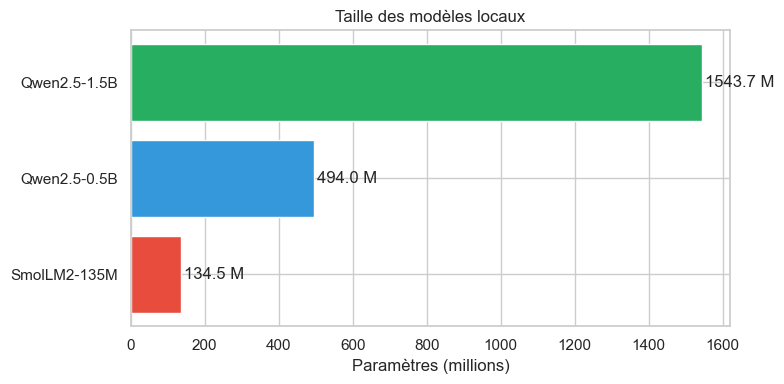

In [6]:
# Visualisation taille des modèles
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_arch["Modèle"], df_arch["Paramètres (M)"], color=["#E74C3C", "#3498DB", "#27AE60"])
ax.set_xlabel("Paramètres (millions)")
ax.set_title("Taille des modèles locaux")
for i, v in enumerate(df_arch["Paramètres (M)"]):
    ax.text(v + 10, i, f"{v} M", va="center")
plt.tight_layout()
plt.show()

## 1.3 Helper : génération avec un modèle local

On encapsule la logique de génération (chat template + tokenisation + decode) dans une fonction réutilisable.

In [7]:
def generate_local(model_key, prompt, max_new_tokens=150, temperature=0.7, top_p=0.9):
    """Génère une réponse avec un modèle local HuggingFace."""
    tok = tokenizers[model_key]
    mdl = models[model_key]

    messages = [{"role": "user", "content": prompt}]
    text = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tok(text, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = mdl.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=temperature > 0,
            pad_token_id=tok.eos_token_id,
        )
    response = tok.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return response.strip()

## 1.4 Helper : appel de l'API Groq

L'API Groq expose une interface **compatible OpenAI** — on utilise le SDK `openai` officiel en changeant juste `base_url` et `api_key`.

Ce pattern est identique pour : OpenAI, Azure OpenAI, Mistral, DeepSeek, Groq, OpenRouter.

In [8]:
def generate_api(prompt, model=None, max_tokens=300, temperature=0.7):
    """Appelle un LLM via l'API Groq (compatible OpenAI)."""
    if not API_AVAILABLE:
        return "[API non configurée — ajoutez votre clé Groq]"

    from openai import OpenAI
    client = OpenAI(
        base_url=GROQ_BASE_URL,
        api_key=GROQ_API_KEY,
    )
    response = client.chat.completions.create(
        model=model or GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        temperature=temperature,
    )
    return response.choices[0].message.content.strip()

## 1.5 Première génération comparée

On pose la même question aux trois modèles locaux et au grand modèle via API.

**Observez :** fluidité, exactitude factuelle, longueur de la réponse. La différence de qualité avec la taille est souvent frappante.

In [9]:
prompt_intro = "Explique en 2 phrases ce qu'est un Large Language Model, dans un contexte professionnel."

print("=" * 80)
for name in MODELS:
    print(f"\n🤖 {name}")
    print("-" * 40)
    print(generate_local(name, prompt_intro, max_new_tokens=120))

print("\n" + "=" * 80)
print(f"\n🌐 API Groq — {GROQ_MODEL}")
print("-" * 40)
print(generate_api(prompt_intro, max_tokens=120))


🤖 SmolLM2-135M
----------------------------------------
The Large Language Model is a computer program designed to analyze and understand complex text data.

🤖 Qwen2.5-0.5B
----------------------------------------
Un Large Language Model (LLM) est une intelligence artificielle qui peut produire des ressources textuelles et langagières. Il utilise des algorithmes de machine learning pour générer de l'information, des propositions ou des textes spécifiques selon les instructions qu'il reçoit. Ces LLMs sont souvent utilisés dans divers domaines professionnels, notamment le développement de documentaires, la rédaction d'emails, l'analyse des données, etc., car ils offrent une facilité d'utilisation inédite et un rendement élevé compar

🤖 Qwen2.5-1.5B
----------------------------------------
Un Large Language Model est une classe d'algorithmes de langage qui sont conçus pour comprendre et produire des textes à partir de données volumineuses d'informations linguistiques. Ces modèles sont gé

---

# PARTIE 2 — Tokenisation en profondeur

La tokenisation est **la première étape de tout LLM**. Elle transforme du texte en une séquence d'entiers que le modèle peut manipuler.

## Rappel théorique

| Algorithme | Principe | Utilisé par |
|------------|----------|-------------|
| **BPE** (Byte Pair Encoding) | Fusionne itérativement les paires de caractères les plus fréquentes | GPT-2, GPT-3, GPT-4, Llama |
| **WordPiece** | Similaire à BPE, gère les sous-mots avec `##` | BERT |
| **SentencePiece (Unigram)** | Modèle probabiliste, apprend directement depuis le texte brut | T5, XLNet, Mistral |
| **Tiktoken (BPE byte-level)** | BPE opérant sur les octets UTF-8 | GPT-3.5, GPT-4, Claude, Qwen |

Les LLM modernes utilisent **majoritairement du BPE byte-level**, car il gère n'importe quelle langue et tout caractère Unicode sans besoin de vocabulaire fixe.

## Points clés

- **1 token ≈ 0,75 mot** en anglais, **≈ 0,5 mot** en français.
- Le coût d'une requête API se facture **au token** (entrée + sortie).
- La **fenêtre de contexte** se mesure en tokens, pas en caractères.

## 2.1 Tokenisation côte-à-côte

On tokenise la même phrase avec les trois tokenizers et on affiche les tokens produits.

In [10]:
def show_tokens(text, tokenizer_name):
    tok = tokenizers[tokenizer_name]
    ids = tok(text, add_special_tokens=False)["input_ids"]
    tokens = [tok.decode([i]) for i in ids]
    print(f"\n{tokenizer_name}  ({len(tokens)} tokens)")
    print("  " + " | ".join(repr(t) for t in tokens))

test_sentences = [
    "L'analyse des flux de données permet de détecter les anomalies.",
    "The Transformer architecture revolutionized natural language processing.",
    "def fibonacci(n): return n if n <= 1 else fibonacci(n-1) + fibonacci(n-2)",
    "Configuration RAG : chunk_size=512, overlap=50, top_k=5, model=bge-m3",
]

for sent in test_sentences:
    print("\n" + "=" * 80)
    print(f"Texte : {sent}")
    for name in MODELS:
        show_tokens(sent, name)



Texte : L'analyse des flux de données permet de détecter les anomalies.

SmolLM2-135M  (20 tokens)
  'L' | "'" | 'analy' | 'se' | ' des' | ' flux' | ' de' | ' don' | 'n' | 'ées' | ' per' | 'met' | ' de' | ' d' | 'ét' | 'ect' | 'er' | ' les' | ' anomalies' | '.'

Qwen2.5-0.5B  (16 tokens)
  'L' | "'" | 'analy' | 'se' | ' des' | ' flux' | ' de' | ' données' | ' permet' | ' de' | ' dét' | 'ect' | 'er' | ' les' | ' anomalies' | '.'

Qwen2.5-1.5B  (16 tokens)
  'L' | "'" | 'analy' | 'se' | ' des' | ' flux' | ' de' | ' données' | ' permet' | ' de' | ' dét' | 'ect' | 'er' | ' les' | ' anomalies' | '.'

Texte : The Transformer architecture revolutionized natural language processing.

SmolLM2-135M  (9 tokens)
  'The' | ' Trans' | 'former' | ' architecture' | ' revolutionized' | ' natural' | ' language' | ' processing' | '.'

Qwen2.5-0.5B  (9 tokens)
  'The' | ' Transformer' | ' architecture' | ' revolution' | 'ized' | ' natural' | ' language' | ' processing' | '.'

Qwen2.5-1.5B  (9 tokens)
  '

## 2.2 Coût en tokens par langue

**Hypothèse à vérifier :** le français coûte-t-il vraiment plus cher que l'anglais ?

In [11]:
multilang_samples = {
    "Français": "L'intelligence artificielle générative transforme l'industrie en automatisant l'analyse, la rédaction et la prise de décision.",
    "Anglais": "Generative AI is transforming industry by automating analysis, writing and decision-making processes.",
    "Espagnol": "La IA generativa está transformando la industria al automatizar el análisis, la escritura y la toma de decisiones.",
    "Allemand": "Generative KI verändert die Industrie durch Automatisierung von Analyse, Texterstellung und Entscheidungsprozessen.",
    "Arabe": "يحول الذكاء الاصطناعي التوليدي الصناعة من خلال أتمتة التحليل والكتابة واتخاذ القرارات.",
    "Chinois": "生成式人工智能正在通过自动化分析、写作和决策来改变各行各业。",
    "Code Python": "def process(data): return [x for x in data if x.is_valid() and x.score > 0.5]",
}

rows = []
for lang, text in multilang_samples.items():
    for name in MODELS:
        n_tokens = len(tokenizers[name](text, add_special_tokens=False)["input_ids"])
        rows.append({"Langue": lang, "Modèle": name, "Tokens": n_tokens, "Chars": len(text)})

df_lang = pd.DataFrame(rows)
pivot = df_lang.pivot(index="Langue", columns="Modèle", values="Tokens")
pivot


Modèle,Qwen2.5-0.5B,Qwen2.5-1.5B,SmolLM2-135M
Langue,,,
Allemand,29,29,37
Anglais,17,17,18
Arabe,34,34,76
Chinois,15,15,48
Code Python,25,25,29
Espagnol,27,27,35
Français,35,35,39


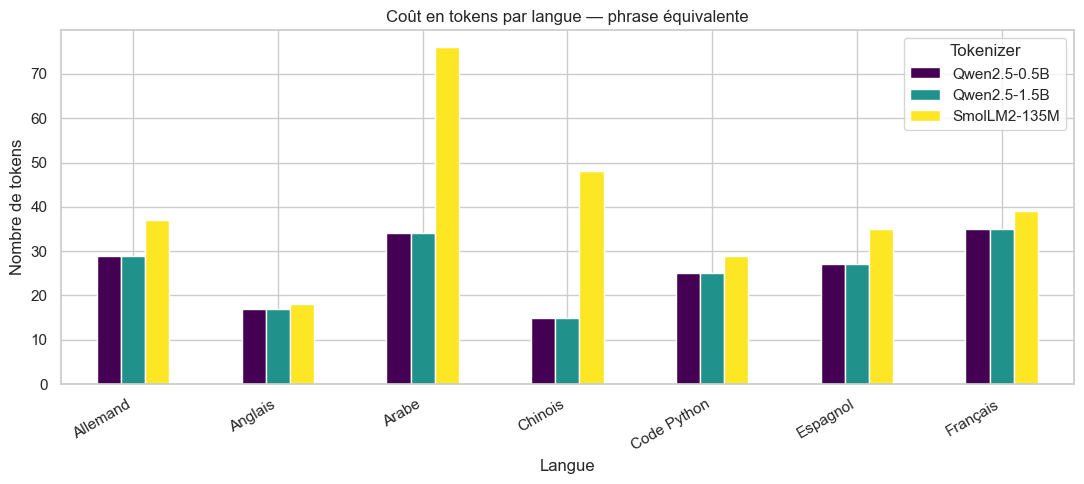

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_ylabel("Nombre de tokens")
ax.set_title("Coût en tokens par langue — phrase équivalente")
ax.legend(title="Tokenizer", loc="upper right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Observations

- Le **français génère 20 à 40 % de tokens en plus** que l'anglais pour le même sens → coût API plus élevé.
- L'**arabe** et le **chinois** peuvent être très variables selon le tokenizer : les tokenizers entraînés sur corpus multilingue récent (Qwen) gèrent mieux.
- **Leçon pratique :** pour une application multilingue, choisir un modèle dont le tokenizer a vu la langue cible pendant l'entraînement.

## 2.3 Cas pathologiques

Certains contenus explosent le nombre de tokens. À connaître pour maîtriser le coût.

In [13]:
pathological_cases = {
    "URL longue": "https://huggingface.co/api/models?search=llama&filter=text-generation&sort=downloads",
    "Token API (gsk)": "gsk_aBcDeFgHiJkLmNoPqRsTuVwXyZ1234567890",
    "Hash long": "a3f5e8d2c4b1a9876543210fedcba9876543210abcdef0123456789abcdef01",
    "Emoji": "🤖🧠💻📊🎯 Modèle entraîné 💯",
    "Nom propre rare": "Andrej Karpathy & Yann LeCun",
    "Mot répété": "yes yes yes yes yes yes yes yes yes yes",
    "Texte JSON": '{"model": "llama-3.3-70b", "tokens": 1500, "latency_ms": 240}',
}

rows = []
for label, text in pathological_cases.items():
    for name in MODELS:
        n = len(tokenizers[name](text, add_special_tokens=False)["input_ids"])
        rows.append({"Cas": label, "Modèle": name, "Tokens": n, "Chars": len(text)})

df_patho = pd.DataFrame(rows)
df_patho.pivot(index="Cas", columns="Modèle", values="Tokens")


Modèle,Qwen2.5-0.5B,Qwen2.5-1.5B,SmolLM2-135M
Cas,,,
Emoji,12,12,26
Hash long,49,49,52
Mot répété,10,10,10
Nom propre rare,11,11,11
Texte JSON,34,34,35
Token API (gsk),33,33,35
URL longue,21,21,27


## 2.4 Visualisation colorée des tokens

Voyons visuellement comment un tokenizer découpe une phrase technique IA / ML.


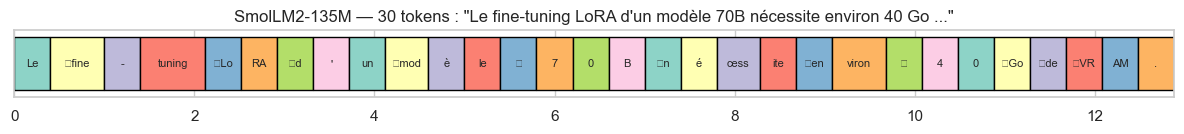

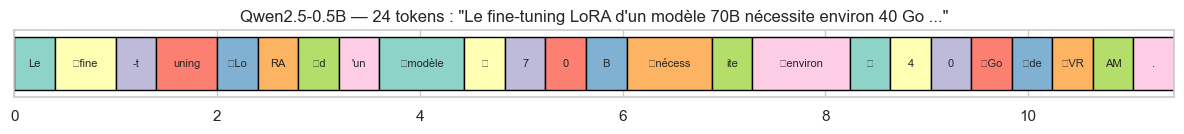

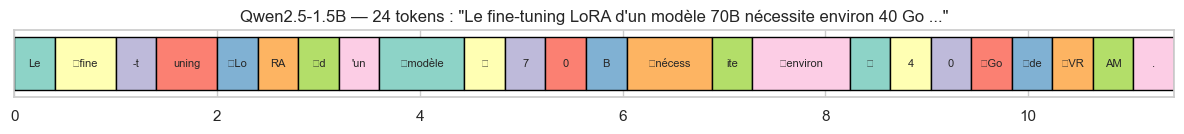

In [14]:
def visualize_tokens(text, tokenizer_name):
    tok = tokenizers[tokenizer_name]
    ids = tok(text, add_special_tokens=False)["input_ids"]
    tokens = [tok.decode([i]) for i in ids]

    # Palette cyclique
    colors = sns.color_palette("Set3", n_colors=max(8, len(tokens) % 12))

    fig, ax = plt.subplots(figsize=(12, 1.5))
    x = 0
    for i, t in enumerate(tokens):
        display = t.replace("\n", "⏎").replace(" ", "␣")
        width = max(0.4, len(display) * 0.12)
        ax.barh(0, width, left=x, height=0.8, color=colors[i % len(colors)], edgecolor="black")
        ax.text(x + width / 2, 0, display, ha="center", va="center", fontsize=8)
        x += width
    ax.set_xlim(0, x)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.set_title(f"{tokenizer_name} — {len(tokens)} tokens : \"{text[:60]}{'...' if len(text) > 60 else ''}\"")
    plt.tight_layout()
    plt.show()

exemple = "Le fine-tuning LoRA d'un modèle 70B nécessite environ 40 Go de VRAM."
for name in MODELS:
    visualize_tokens(exemple, name)


## 2.5 Analyse du vocabulaire

Qu'y a-t-il dans le vocabulaire ? Tokens spéciaux, tokens français, tokens techniques IA / ML ?


In [15]:
for name in MODELS:
    tok = tokenizers[name]
    print(f"\n{'=' * 60}")
    print(f"📖 {name}")
    print(f"{'=' * 60}")
    print(f"  Taille vocabulaire : {tok.vocab_size:,}")
    print(f"  Token de fin       : {tok.eos_token} (id={tok.eos_token_id})")
    print(f"  Token padding      : {tok.pad_token}")

    # Cherche quelques mots techniques IA / ML dans le vocab
    vocab = tok.get_vocab()
    for word in ["transformer", "attention", "embedding", "fine-tuning", "RAG", "token"]:
        # Tokenisation individuelle pour voir s'il existe en un seul token
        ids = tok(word, add_special_tokens=False)["input_ids"]
        status = "1 token" if len(ids) == 1 else f"{len(ids)} tokens"
        print(f"    \"{word}\" → {status} : {[tok.decode([i]) for i in ids]}")



📖 SmolLM2-135M
  Taille vocabulaire : 49,152
  Token de fin       : <|im_end|> (id=2)
  Token padding      : <|im_end|>
    "transformer" → 2 tokens : ['transform', 'er']
    "attention" → 1 token : ['attention']
    "embedding" → 1 token : ['embedding']
    "fine-tuning" → 3 tokens : ['fine', '-', 'tuning']
    "RAG" → 2 tokens : ['R', 'AG']
    "token" → 1 token : ['token']

📖 Qwen2.5-0.5B
  Taille vocabulaire : 151,643
  Token de fin       : <|im_end|> (id=151645)
  Token padding      : <|endoftext|>
    "transformer" → 2 tokens : ['transform', 'er']
    "attention" → 1 token : ['attention']
    "embedding" → 1 token : ['embedding']
    "fine-tuning" → 3 tokens : ['fine', '-t', 'uning']
    "RAG" → 2 tokens : ['R', 'AG']
    "token" → 1 token : ['token']

📖 Qwen2.5-1.5B
  Taille vocabulaire : 151,643
  Token de fin       : <|im_end|> (id=151645)
  Token padding      : <|endoftext|>
    "transformer" → 2 tokens : ['transform', 'er']
    "attention" → 1 token : ['attention']
    "emb

## 2.6 Estimation du coût d'un document technique

Mise en pratique : estimons combien coûterait le traitement d'un rapport technique IA / ML typique.


In [16]:
rapport_extrait = """
Rapport trimestriel Q1 2026 — Plateforme RAG en production

Au cours du premier trimestre 2026, la plateforme RAG a traité 4,2 millions de
requêtes utilisateurs, en progression de 6,3 % par rapport au trimestre précédent.
Le taux de hallucinations résiduelles reste maîtrisé à 3,8 %, soit une baisse de
0,2 point grâce au déploiement du re-ranker cross-encoder.

L'index vectoriel a connu une croissance organique de 8,1 %, porté principalement
par l'ingestion automatique de la documentation technique et des nouveaux corpus
de papiers scientifiques.

Le passage à llama-3.3-70b-versatile via Groq a généré une réduction du coût
d'inférence de 35 %, grâce à la latence p95 sous 200 ms et au tier gratuit.
"""

# Coût indicatif d'un appel API (entrée + sortie supposée équivalente)
# Tarifs illustratifs en $/1M tokens (à ajuster selon le modèle)
pricing = {
    "GPT-4o":         {"input": 2.50,  "output": 10.00},
    "Claude Sonnet":  {"input": 3.00,  "output": 15.00},
    "Llama 3.3 70B (Groq)": {"input": 0.59, "output": 0.79},
    "Mistral Small":  {"input": 0.20,  "output": 0.60},
}

# On utilise le tokenizer Qwen2.5 comme proxy (BPE byte-level, comparable GPT/Claude)
tok_proxy = tokenizers["Qwen2.5-1.5B"]
n_in = len(tok_proxy(rapport_extrait, add_special_tokens=False)["input_ids"])
n_out_est = n_in  # hypothèse : sortie ≈ entrée

print(f"Tokens en entrée  : {n_in}")
print(f"Tokens en sortie (estimés) : {n_out_est}")
print(f"\nCoût d'un appel unique (estimation en $)")
print(f"{'Modèle':<25} {'Coût ($)':<12}")
print("-" * 37)
for model, rates in pricing.items():
    cost = (n_in * rates["input"] + n_out_est * rates["output"]) / 1_000_000
    print(f"{model:<25} {cost:.6f}")

print(f"\nPour 10 000 rapports/mois : × 10 000")


Tokens en entrée  : 217
Tokens en sortie (estimés) : 217

Coût d'un appel unique (estimation en $)
Modèle                    Coût ($)    
-------------------------------------
GPT-4o                    0.002713
Claude Sonnet             0.003906
Llama 3.3 70B (Groq)      0.000299
Mistral Small             0.000174

Pour 10 000 rapports/mois : × 10 000


---

# PARTIE 3 — Embeddings

Après la tokenisation, chaque token est projeté dans un **vecteur dense** (embedding). C'est la représentation que le modèle manipule vraiment.

## Deux notions à distinguer

| Type | Description |
|------|-------------|
| **Embeddings de tokens** (statiques) | Matrice apprise par le modèle ; chaque token du vocab a un vecteur fixe. |
| **Embeddings contextuels** | Sortie d'une couche interne du modèle ; dépendent du contexte. Le mot « avocat » aura un vecteur différent en contexte juridique ou culinaire. |
| **Sentence embeddings** | Vecteur représentant une phrase entière ; produit par des modèles comme `sentence-transformers`. Pratique pour RAG, recherche sémantique. |

## 3.1 Extraction de la matrice d'embedding d'un LLM

Chaque LLM contient une matrice `vocab_size × hidden_size` accessible via sa couche d'embedding.

In [17]:
name = "Qwen2.5-1.5B"
embedding_layer = models[name].get_input_embeddings()
emb_matrix = embedding_layer.weight.detach().cpu().numpy()

print(f"Modèle : {name}")
print(f"Forme de la matrice d'embedding : {emb_matrix.shape}")
print(f"  → {emb_matrix.shape[0]:,} tokens × {emb_matrix.shape[1]} dimensions")
print(f"Taille mémoire : {emb_matrix.nbytes / 1e6:.1f} MB")

Modèle : Qwen2.5-1.5B
Forme de la matrice d'embedding : (151936, 1536)
  → 151,936 tokens × 1536 dimensions
Taille mémoire : 933.5 MB


## 3.2 Récupérer l'embedding d'un mot

On extrait le vecteur correspondant à quelques mots clés. Puis on calcule la **similarité cosinus** entre paires.

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

def word_embedding(word, layer=emb_matrix):
    """Récupère l'embedding moyen d'un mot (1 ou plusieurs sous-tokens)."""
    tok = tokenizers[name]
    ids = tok(word, add_special_tokens=False)["input_ids"]
    vecs = layer[ids]
    return vecs.mean(axis=0)


mots = ["transformer", "attention", "embedding", "fine-tuning", "GPU", "chat", "voiture"]
embs = np.array([word_embedding(m) for m in mots])
sim_matrix = cosine_similarity(embs)

import pandas as pd
df_sim = pd.DataFrame(sim_matrix, index=mots, columns=mots).round(3)
df_sim


,transformer,attention,embedding,fine-tuning,GPU,chat,voiture
transformer,1.000,0.021,0.040,-0.020,0.007,-0.023,0.032
attention,0.021,1.000,0.115,0.065,0.046,0.055,0.094
embedding,0.040,0.115,1.000,0.100,0.125,0.084,0.113
fine-tuning,-0.020,0.065,0.100,1.000,0.060,0.053,0.092
GPU,0.007,0.046,0.125,0.060,1.000,0.062,0.090
chat,-0.023,0.055,0.084,0.053,0.062,1.000,0.062
voiture,0.032,0.094,0.113,0.092,0.090,0.062,1.000


### Remarque importante

Les embeddings **statiques** extraits directement de la matrice d'un LLM ne sont pas idéaux pour la recherche sémantique. Ils ne prennent pas le contexte en compte.

Pour du RAG ou de la similarité de phrases, on utilise plutôt des **sentence-transformers** (voir section 3.4).

## 3.3 Visualisation PCA du vocabulaire métier

On projette les embeddings de plusieurs mots en 2D (PCA) pour visualiser les clusters sémantiques.

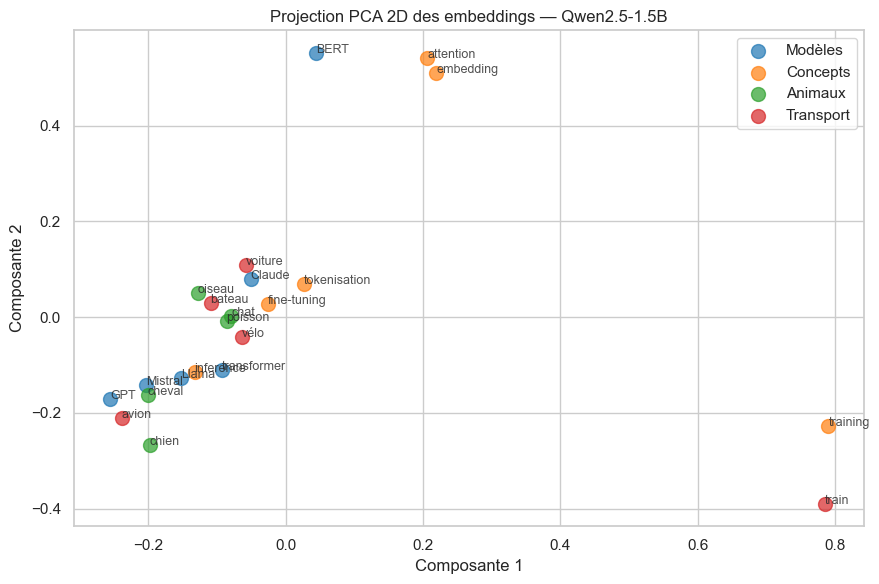

In [19]:
from sklearn.decomposition import PCA

vocabulaire = {
    "Modèles":   ["transformer", "BERT", "GPT", "Llama", "Mistral", "Claude"],
    "Concepts":  ["attention", "embedding", "tokenisation", "fine-tuning", "inference", "training"],
    "Animaux":   ["chat", "chien", "oiseau", "poisson", "cheval"],
    "Transport": ["voiture", "train", "avion", "bateau", "vélo"],
}

mots_all = []
categories = []
for cat, mots in vocabulaire.items():
    for m in mots:
        mots_all.append(m)
        categories.append(cat)

X = np.array([word_embedding(m) for m in mots_all])
X_2d = PCA(n_components=2).fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 6))
palette = {"Modèles": "#1f77b4", "Concepts": "#ff7f0e", "Animaux": "#2ca02c", "Transport": "#d62728"}
for cat in vocabulaire:
    mask = [c == cat for c in categories]
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=cat, s=100, alpha=0.7, color=palette[cat])
for i, mot in enumerate(mots_all):
    ax.annotate(mot, (X_2d[i, 0], X_2d[i, 1]), fontsize=9, alpha=0.8)
ax.legend()
ax.set_title(f"Projection PCA 2D des embeddings — {name}")
ax.set_xlabel("Composante 1")
ax.set_ylabel("Composante 2")
plt.tight_layout()
plt.show()


**Observation :** les clusters par champ lexical ne se détachent pas clairement sur ce PCA 2D. On devine quelques regroupements (les termes IA *transformer, attention, embedding* se concentrent souvent dans une zone, *chat / chien / oiseau* dans une autre), mais les frontières sont floues. Pourquoi ?

1. Ce sont les **embeddings d'entrée** du modèle (matrice `embed_tokens`), donc **statiques et non contextuels** : le vecteur de *chat* est le même qu'on parle d'un chat-animal ou de la commande shell.
2. Pour un clustering net par champ lexical, on utilise plutôt :
   - les **embeddings contextuels** (sortie d'une couche cachée intermédiaire) ;
   - ou un **sentence-transformer** entraîné explicitement pour la similarité (cf. § 3.4).


## 3.4 Sentence embeddings avec `sentence-transformers`

Pour la recherche sémantique (RAG, classification, clustering de phrases), on utilise des modèles spécialisés qui produisent un **seul vecteur par phrase**, optimisé pour la similarité.

Modèle choisi : `paraphrase-multilingual-MiniLM-L12-v2` — multilingue, compact, français inclus.

In [20]:
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
print(f"Modèle chargé : {st_model}")
print(f"Dimension des embeddings : {st_model.get_sentence_embedding_dimension()}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Modèle chargé : SentenceTransformer(
  (0): Transformer({'max_seq_length': 128, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
)
Dimension des embeddings : 384


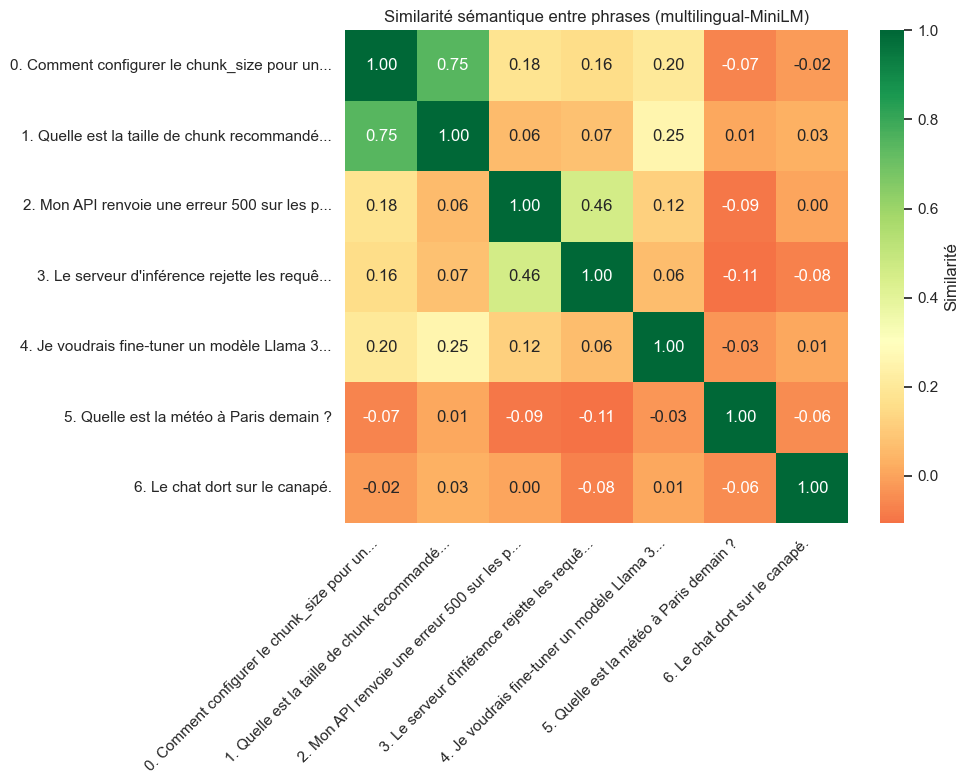

In [21]:
phrases = [
    "Comment configurer le chunk_size pour un pipeline RAG ?",
    "Quelle est la taille de chunk recommandée en RAG ?",
    "Mon API renvoie une erreur 500 sur les prompts longs.",
    "Le serveur d'inférence rejette les requêtes de plus de 4000 tokens.",
    "Je voudrais fine-tuner un modèle Llama 3 sur mon GPU.",
    "Quelle est la météo à Paris demain ?",
    "Le chat dort sur le canapé.",
]

emb_phrases = st_model.encode(phrases, convert_to_numpy=True)
sim_matrix = cosine_similarity(emb_phrases)

fig, ax = plt.subplots(figsize=(10, 8))
labels = [f"{i}. {p[:40]}..." if len(p) > 40 else f"{i}. {p}" for i, p in enumerate(phrases)]
sns.heatmap(sim_matrix, xticklabels=labels, yticklabels=labels, annot=True,
            fmt=".2f", cmap="RdYlGn", center=0.3, ax=ax, cbar_kws={"label": "Similarité"})
ax.set_title("Similarité sémantique entre phrases (multilingual-MiniLM)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Ce qu'on observe

- Phrases 0/1 (chunk_size pour RAG / taille de chunk) → très similaires ✓
- Phrases 2/3 (erreur API 500 / prompts trop longs) → très similaires ✓
- Ces paires sont des **paraphrases** mais avec des mots différents — les sentence embeddings capturent le **sens**, pas les mots.
- Phrases 5 (météo) et 6 (chat) → éloignées de toutes les phrases techniques ✓

C'est exactement cette capacité qui fait fonctionner un système **RAG** : retrouver les passages pertinents par similarité sémantique.


## 3.5 Arithmétique vectorielle : une propriété émergente

L'exemple célèbre : `roi - homme + femme ≈ reine`.

Testons sur vocabulaire IA / ML : `BERT - encoder + decoder ≈ ?`


In [22]:
def analogy(a, b, c, candidates, model):
    """Trouve le mot qui complète : a est à b ce que c est à ?"""
    vec = (model.encode([a], convert_to_numpy=True)[0]
           - model.encode([b], convert_to_numpy=True)[0]
           + model.encode([c], convert_to_numpy=True)[0])
    cand_vecs = model.encode(candidates, convert_to_numpy=True)
    sims = cosine_similarity([vec], cand_vecs)[0]
    ranked = sorted(zip(candidates, sims), key=lambda x: -x[1])
    return ranked

candidats = ["GPT", "T5", "Llama", "BART", "Whisper", "Mistral", "Gemini",
             "RoBERTa", "ALBERT", "DistilBERT", "ELECTRA"]

print("Analogie : encoder est à BERT ce que decoder est à ?")
print("Formule  : BERT - encoder + decoder ≈ ?\n")
results = analogy("encoder", "BERT", "decoder", candidats, st_model)
for mot, score in results[:5]:
    print(f"  {mot:<15} {score:.3f}")


Analogie : encoder est à BERT ce que decoder est à ?
Formule  : BERT - encoder + decoder ≈ ?

  Mistral         0.117
  ELECTRA         0.115
  Whisper         0.101
  GPT             0.053
  DistilBERT      0.052


---

# PARTIE 4 — Génération et stratégies de décodage

Lors de la génération, un LLM produit à chaque pas une **distribution de probabilités** sur tout son vocabulaire. Il faut **choisir** un token dans cette distribution.

## Les paramètres clés

| Paramètre | Effet |
|-----------|-------|
| **Greedy** | Prend toujours le token le plus probable. Déterministe. |
| **Sampling** | Tire un token au hasard selon la distribution. |
| **Beam search** | Explore plusieurs hypothèses en parallèle, garde les meilleures séquences. |
| **Temperature** | Aplatit (T grand) ou pique (T petit) la distribution. T=0 ≡ greedy. |
| **Top-k** | Ne considère que les k tokens les plus probables. |
| **Top-p (nucleus)** | Ne considère que les tokens dont la somme de probas atteint p. |
| **Repetition penalty** | Pénalise les tokens déjà générés. |

## 4.1 Greedy vs Sampling vs Beam search

In [23]:
MODEL_KEY = "Qwen2.5-1.5B"
prompt = "Rédige un court paragraphe sur l'avenir des agents IA en entreprise."

print("=" * 60)
print("Greedy (déterministe, choisit toujours le top-1)")
print("=" * 60)
set_seed(42)
print(generate_local(MODEL_KEY, prompt, max_new_tokens=80, temperature=0.0, top_p=1.0))

print("\n\n" + "=" * 60)
print("Sampling (T=0.7, top_p=0.9 — équilibre cohérence / diversité)")
print("=" * 60)
for run in range(3):
    set_seed(42 + run)
    print(f"\n--- Run {run+1} ---")
    print(generate_local(MODEL_KEY, prompt, max_new_tokens=80, temperature=0.7, top_p=0.9))


Greedy (déterministe, choisit toujours le top-1)
L'avenir des agents d'intelligence artificielle (IA) dans les entreprises se présente sous plusieurs facettes prometteuses et complexes. En tant que technologie avancée, l'IA est devenue une composante essentielle du processus de décision stratégique et opérationnel des organisations. Elle permet non seulement d'améliorer la productivité et la préc


Sampling (T=0.7, top_p=0.9 — équilibre cohérence / diversité)

--- Run 1 ---
L'avenir des agents d'intelligence artificielle (IA) dans les entreprises se présente sous forme de collaboration et d'adaptation à des besoins variés. Les systèmes d'IA continueront à évoluer pour devenir plus intelligents et flexibles, améliorant la performance globale de l'entreprise tout en maintenant une qualité de service exception

--- Run 2 ---
L'avenir des agents d'intelligence artificielle (IA) dans les entreprises est prometteur et complexe. À mesure que le développement de la technologie avance, les appl

## 4.2 Sweep de température

On fixe tout sauf la température. Observez l'évolution : de « figé » à « créatif/délirant ».

In [24]:
prompt_creatif = "La prochaine rupture en intelligence artificielle sera probablement"
temperatures = [0.1, 0.3, 0.7, 1.0, 1.5]

for T in temperatures:
    set_seed(42)
    response = generate_local(MODEL_KEY, prompt_creatif, max_new_tokens=60, temperature=T, top_p=0.95)
    print(f"\nT = {T}")
    print(f"  → {response}")



T = 0.1
  → Je suis désolé, mais je ne peux pas prédire avec certitude la prochaine rupture dans l'intelligence artificielle ou toute autre technologie. Les avancées techniques sont souvent très rapides et imprévisibles. Cependant, il est certain que

T = 0.3
  → Je suis désolé, mais je ne peux pas prédire avec certitude la prochaine rupture dans l'intelligence artificielle ou d'autres technologies futures. Les avancées technologiques sont souvent imprévues et dépendent de nombreux facteurs complexes.

Cepend

T = 0.7
  → Je suis désolé, mais je ne peux pas prédire avec certitude la date ou le type de nouvelle technologie qui pourrait être la prochaine rupture importante en Intelligence Artificielle (IA). L'avancement rapide et innovant de l'IA est caractéristique

T = 1.0
  → Dans l'histoire de l'intelligence artificielle, nous avons parcouru plusieurs phases et voies possibles dans notre évolution. 

1. L'intelligence Artificielle (IA) de base: Cela comprenait le développement des s

## 4.3 Visualisation des probabilités top-k

On exécute la boucle de génération **manuellement** pour capturer les distributions à chaque pas.

In [25]:
def generate_with_probs(model_key, prompt, max_new_tokens=15, top_k=5):
    tok = tokenizers[model_key]
    mdl = models[model_key]
    messages = [{"role": "user", "content": prompt}]
    text = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tok(text, return_tensors="pt").to(DEVICE)
    input_ids = inputs["input_ids"]

    steps = []
    for _ in range(max_new_tokens):
        with torch.no_grad():
            out = mdl(input_ids)
        logits = out.logits[0, -1, :]
        probs = torch.softmax(logits, dim=-1)
        topk = torch.topk(probs, top_k)
        top_tokens = [(tok.decode([int(t)]).replace("\n", "⏎"), float(p))
                      for t, p in zip(topk.indices, topk.values)]
        chosen = int(topk.indices[0])
        steps.append({"top_k": top_tokens, "chosen": tok.decode([chosen])})
        input_ids = torch.cat([input_ids, torch.tensor([[chosen]]).to(DEVICE)], dim=1)
        if chosen == tok.eos_token_id:
            break
    return steps

steps = generate_with_probs(MODEL_KEY, "L'IA générative sert à", max_new_tokens=10, top_k=5)

for i, s in enumerate(steps):
    print(f"\nÉtape {i+1} — choisi : \"{s['chosen']}\"")
    for t, p in s["top_k"]:
        bar = "█" * int(p * 40)
        print(f"  {p:.3f} {bar} {repr(t)}")



Étape 1 — choisi : "L"
  0.512 ████████████████████ 'L'
  0.323 ████████████ 'La'
  0.029 █ 'Les'
  0.028 █ 'Le'
  0.013  'la'

Étape 2 — choisi : "'"
  0.741 █████████████████████████████ "'"
  0.229 █████████ "'int"
  0.011  "'utilisation"
  0.007  "'app"
  0.004  "'I"

Étape 3 — choisi : "IA"
  0.988 ███████████████████████████████████████ 'IA'
  0.007  'Int'
  0.002  'AI'
  0.000  'art'
  0.000  'INT'

Étape 4 — choisi : " génér"
  0.923 ████████████████████████████████████ ' génér'
  0.064 ██ ' géné'
  0.005  ' ('
  0.004  ' gén'
  0.001  ' gener'

Étape 5 — choisi : "ative"
  1.000 ███████████████████████████████████████ 'ative'
  0.000  'atrice'
  0.000  'atif'
  0.000  'atives'
  0.000  'ativa'

Étape 6 — choisi : " est"
  0.391 ███████████████ ' est'
  0.328 █████████████ ' s'
  0.095 ███ ' peut'
  0.053 ██ ','
  0.048 █ ' ('

Étape 7 — choisi : " utilis"
  0.281 ███████████ ' utilis'
  0.218 ████████ ' une'
  0.166 ██████ ' un'
  0.128 █████ ' princip'
  0.034 █ ' géné'

Éta

## 4.4 Entropie : mesurer l'incertitude

L'**entropie de Shannon** mesure l'incertitude d'une distribution :

$$H = -\sum_i p_i \log p_i$$

- Entropie **basse** : le modèle est sûr (une option domine).
- Entropie **haute** : le modèle hésite entre beaucoup d'options.

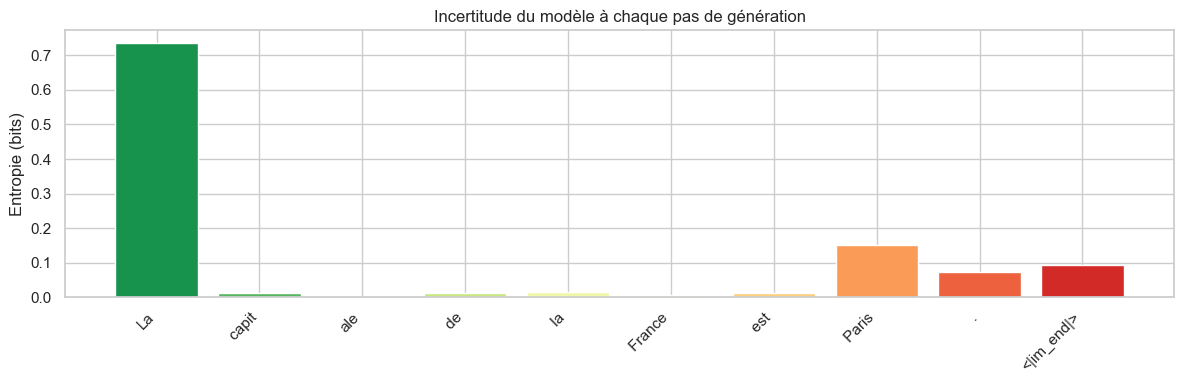

In [26]:
def compute_entropy(logits, temperature=1.0):
    scaled = logits / temperature
    probs = torch.softmax(scaled, dim=-1)
    log_probs = torch.log(probs + 1e-10)
    return -(probs * log_probs).sum().item()

def generate_with_entropy(model_key, prompt, max_new_tokens=25):
    tok = tokenizers[model_key]
    mdl = models[model_key]
    messages = [{"role": "user", "content": prompt}]
    text = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tok(text, return_tensors="pt").to(DEVICE)
    input_ids = inputs["input_ids"]

    entropies, tokens = [], []
    for _ in range(max_new_tokens):
        with torch.no_grad():
            out = mdl(input_ids)
        logits = out.logits[0, -1, :]
        entropies.append(compute_entropy(logits))
        chosen = int(torch.argmax(logits))
        tokens.append(tok.decode([chosen]))
        input_ids = torch.cat([input_ids, torch.tensor([[chosen]]).to(DEVICE)], dim=1)
        if chosen == tok.eos_token_id:
            break
    return tokens, entropies

tokens, entropies = generate_with_entropy(MODEL_KEY, "La capitale de la France est", max_new_tokens=20)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(entropies)), entropies, color=sns.color_palette("RdYlGn_r", n_colors=len(entropies)))
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels([t.replace("\n", "⏎") for t in tokens], rotation=45, ha="right")
ax.set_ylabel("Entropie (bits)")
ax.set_title("Incertitude du modèle à chaque pas de génération")
plt.tight_layout()
plt.show()

## 4.5 Repetition penalty

Les petits modèles tombent souvent dans des boucles. Le paramètre `repetition_penalty > 1` les pénalise.

In [27]:
prompt_rep = "Liste cinq avantages d'un agent IA pour automatiser des tâches répétitives."
for penalty in [1.0, 1.1, 1.3]:
    set_seed(42)
    tok = tokenizers["SmolLM2-135M"]
    mdl = models["SmolLM2-135M"]
    messages = [{"role": "user", "content": prompt_rep}]
    text = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tok(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = mdl.generate(**inputs, max_new_tokens=120, do_sample=False,
                           repetition_penalty=penalty, pad_token_id=tok.eos_token_id)
    print(f"\nrepetition_penalty = {penalty}\n{'-' * 40}")
    print(tok.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip())



repetition_penalty = 1.0
----------------------------------------
1. **Automate the execution of tasks**: IA can automate the execution of tasks, such as setting up a new account, creating a new account, or updating an account.

2. **Automate the creation of new accounts**: IA can create new accounts, which can be done automatically, without the need for manual intervention.

3. **Automate the creation of new accounts**: IA can create new accounts, which can be done automatically, without the need for manual intervention.

4. **Automate the creation of new accounts**: IA can create new accounts, which can be done

repetition_penalty = 1.1
----------------------------------------
1. **Automate the execution of tasks**: IA can automate the process of executing tasks on behalf of an agent, reducing manual labor and increasing efficiency.

2. **Enhance task completion rates**: IA can improve the accuracy and speed of tasks performed by agents, leading to higher productivity and better out

---

# PARTIE 5 — Cas d'usage métier (IA / LLM / RAG / dev)

On passe maintenant à la pratique : six cas d'usage typiques en ingénierie IA, comparés entre un **petit modèle local** et un **grand modèle via API**.

Méthode : même prompt, on observe qualité, cohérence, respect du format demandé.


## 5.1 Cas 1 — Résumé

Résumer un extrait de rapport. Test classique : compression d'information avec préservation du sens.

In [28]:
texte_long = """
Au premier trimestre 2026, l'écosystème des grands modèles de langage a connu
une accélération significative. Llama 3.3 (Meta) et Qwen 2.5 (Alibaba) atteignent
les performances de GPT-4 sur de nombreux benchmarks, à un coût d'inférence
10 à 30 fois inférieur. Le passage à l'inférence accélérée par LPU (Groq, Cerebras)
réduit la latence end-to-end de 3 secondes à environ 200 ms. Le coût d'entraînement
des modèles 70B reste un frein majeur (plusieurs millions de dollars par run),
mais le fine-tuning paramétriquement efficace (LoRA, QLoRA, adapters) démocratise
l'adaptation sur des GPU grand public (16 à 24 Go). Côté évaluation, RAGas et
TruLens deviennent les standards de mesure des pipelines RAG en production,
avec une focalisation croissante sur la Faithfulness et la Context Precision.
"""

prompt_resume = f"Résume le texte suivant en 3 points clés, style télégraphique :\n\n{texte_long}"

print("🤖 SmolLM2-135M (local, ~135M params)")
print("-" * 60)
print(generate_local("SmolLM2-135M", prompt_resume, max_new_tokens=150))

print("\n\n🤖 Qwen2.5-1.5B (local, ~1.5B params)")
print("-" * 60)
print(generate_local("Qwen2.5-1.5B", prompt_resume, max_new_tokens=150))

print("\n\n🌐 API Groq (Llama 3.3 70B Versatile)")
print("-" * 60)
print(generate_api(prompt_resume, max_tokens=150))


🤖 SmolLM2-135M (local, ~135M params)
------------------------------------------------------------
L'écosystème de langage a connu était l'université à 2026, à 2026, à 2024, à 2023, à 2022, à 2021, à 2020, à 2019, à 2018, à 2017, à 2016, à 2015, à 2014, à 2013, à 2012, à 2011, à 2010, à 2009, à 2


🤖 Qwen2.5-1.5B (local, ~1.5B params)
------------------------------------------------------------
• Performance exponentiellement accrue pour les grandes architectures de langage, avec des gains significatifs comparés à GPT-4.

• Réduction drastique du temps d'inference grâce au Groq/LPU technique, allant jusqu'à 200 ms.

• Coût d'entraînement réduit pour les modèles de taille 70M, avec une moyenne de plusieurs millions de dollars par cycle.

• Évaluation robuste de pipeline RAG grâce aux technologies LoRA/QLoRA et à la mise en place d'une focalisation sur les critères de Faithfulness et Context Precision.


🌐 API Groq (Llama 3.3 70B Versatile)
------------------------------------------------

## 5.2 Cas 2 — Classification de tickets support

On passe maintenant à un classifieur typique en plateforme IA / dev : tickets utilisateurs catégorisés automatiquement.

Catégories : `BUG`, `FEATURE_REQUEST`, `PERFORMANCE`, `DOCS`, `QUESTION`.

On compare **zero-shot** vs **few-shot** sur les mêmes tickets.


In [29]:
tickets = [
    "L'API renvoie une 500 quand le prompt dépasse 4000 tokens, alors que la doc dit 8192.",
    "Pouvez-vous ajouter le support du streaming pour les réponses longues ?",
    "La latence p95 a doublé depuis la release 2.4.1, ça impacte ma prod.",
    "La doc ne précise pas comment configurer le timeout côté client.",
    "Comment fonctionne le re-ranking cross-encoder dans votre pipeline RAG ?",
]

categories = ["BUG", "FEATURE_REQUEST", "PERFORMANCE", "DOCS", "QUESTION"]

# --- Zero-shot ---
prompt_zs = lambda t: (
    f"Catégorise le ticket utilisateur suivant parmi ces catégories : {', '.join(categories)}. "
    f"Réponds uniquement par le nom exact de la catégorie.\n\nTicket : {t}\nCatégorie :"
)

# --- Few-shot ---
few_shot_examples = """
Ticket : Crash sur prompt vide.
Catégorie : BUG

Ticket : Je voudrais pouvoir streamer les réponses au lieu d'attendre la fin.
Catégorie : FEATURE_REQUEST

Ticket : La documentation des codes d'erreur est incomplète.
Catégorie : DOCS
"""

prompt_fs = lambda t: (
    f"Catégorise les tickets utilisateurs parmi : {', '.join(categories)}.{few_shot_examples}\n"
    f"Ticket : {t}\nCatégorie :"
)

print(f"{'Ticket':<60} {'Zero-shot':<18} {'Few-shot':<18}")
print("-" * 96)
for t in tickets:
    zs = generate_local("Qwen2.5-1.5B", prompt_zs(t), max_new_tokens=10, temperature=0.0).split()[0]
    fs = generate_local("Qwen2.5-1.5B", prompt_fs(t), max_new_tokens=10, temperature=0.0).split()[0]
    print(f"{t[:55]:<60} {zs:<18} {fs:<18}")


Ticket                                                       Zero-shot          Few-shot          
------------------------------------------------------------------------------------------------
L'API renvoie une 500 quand le prompt dépasse 4000 toke      BUG                Ticket            
Pouvez-vous ajouter le support du streaming pour les ré      FEATURE_REQUEST    Ticket            
La latence p95 a doublé depuis la release 2.4.1, ça imp      PERFORMANCE        Ticket            
La doc ne précise pas comment configurer le timeout côt      DOCS               Ticket            
Comment fonctionne le re-ranking cross-encoder dans vot      QUESTION           Ticket            


**À retenir :** quelques exemples (few-shot) stabilisent souvent la sortie et forcent le format attendu, même sur un petit modèle.

## 5.3 Cas 3 — Traduction multilingue

Les LLM modernes ont été entraînés sur corpus multilingue : ils font de la traduction sans fine-tuning spécifique.

In [30]:
phrases_trad = [
    ("FR → EN", "Le fine-tuning paramétriquement efficace réduit drastiquement le coût d'adaptation."),
    ("FR → AR", "Le retrieval hybride combine BM25 et embeddings denses via RRF."),
    ("EN → FR", "Cross-encoder reranking improves the faithfulness of RAG pipelines."),
]

for direction, phrase in phrases_trad:
    prompt_trad = f"Traduis précisément la phrase suivante, direction {direction}. Réponds uniquement avec la traduction.\n\n{phrase}"
    print(f"\n{direction}")
    print(f"Source  : {phrase}")
    print(f"Qwen    : {generate_local('Qwen2.5-1.5B', prompt_trad, max_new_tokens=80, temperature=0.3)}")
    print(f"API     : {generate_api(prompt_trad, max_tokens=80, temperature=0.3)}")



FR → EN
Source  : Le fine-tuning paramétriquement efficace réduit drastiquement le coût d'adaptation.
Qwen    : The effective parameter-free fine-tuning drastically reduces the adaptation cost.
API     : Parametrically efficient fine-tuning drastically reduces the cost of adaptation.

FR → AR
Source  : Le retrieval hybride combine BM25 et embeddings denses via RRF.
Qwen    : البحث المركزي المزدوج يجمع بين بيمان 25 و embeddings الدقيقين عبر رفرف.
API     : الاسترجاع الهجين يجمع بين BM25 والتحويلات الكثيفة من خلال RRF.

EN → FR
Source  : Cross-encoder reranking improves the faithfulness of RAG pipelines.
Qwen    : La rétropédologie basée sur l'encodage croisé améliore la fidélité des pipelines de RAG.
API     : Le re classement par cross-encoder améliore la fidélité des pipelines RAG.


## 5.4 Cas 4 — Extraction structurée (texte → JSON)

Cas typique : un utilisateur reporte un bug par email, on veut extraire les champs structurés (release, modèle, comportement, contact, pièces jointes) en JSON pour alimenter un système de tickets.


In [31]:
bug_report = """
Bonjour,
Je rencontre un bug bloquant sur votre pipeline RAG depuis la release 2.4.1
(déployée le 22 avril 2026). Sur les questions hors-domaine, le modèle
llama-3.3-70b-versatile (provider Groq) hallucine au lieu de répondre
"information non disponible". Stack : embedding bge-m3, corpus 80k docs,
chunk_size=512.
Impact : 3 incidents clients cette semaine.
Logs joints : trace.json, prompt_full.txt.
Mon contact : sarah.k@example.com (USR-7821).
"""

schema = """
{
  "type_demande": "<bug | feature | question>",
  "release": "<version>",
  "date_release": "<YYYY-MM-DD>",
  "modele_llm": "<nom du modèle>",
  "provider": "<provider>",
  "stack": {"embedding": "<modèle>", "chunk_size": <nombre>},
  "comportement_observe": "<texte>",
  "impact": "<texte>",
  "pieces_jointes": ["<fichier>", ...],
  "rapporteur": {"contact": "<email>", "user_id": "<id>"}
}
"""

prompt_extract = (
    f"Extrais les informations du bug report ci-dessous au format JSON strict, en suivant ce schéma :\n{schema}\n\n"
    f"Bug report :\n{bug_report}\n\n"
    f"Réponds uniquement avec le JSON, sans texte autour."
)

print("🤖 Qwen2.5-1.5B (local)")
print("-" * 60)
print(generate_local("Qwen2.5-1.5B", prompt_extract, max_new_tokens=300, temperature=0.0))

print("\n🌐 API Groq")
print("-" * 60)
print(generate_api(prompt_extract, max_tokens=300, temperature=0.0))


🤖 Qwen2.5-1.5B (local)
------------------------------------------------------------
```json
{
  "type_demande": "bug",
  "release": "2.4.1",
  "date_release": "2026-04-22",
  "modele_llm": "llama-3.3-70b-versatile",
  "provider": "Groq",
  "stack": {
    "embedding": "bge-m3",
    "chunk_size": 512
  },
  "comportement_observe": "Le modèle hallucine pour les questions hors-domaine.",
  "impact": "3 incidents clients cette semaine.",
  "pieces_jointes": [
    "trace.json",
    "prompt_full.txt"
  ],
  "rapporteur": {
    "contact": "sarah.k@example.com",
    "user_id": "USR-7821"
  }
}
```

🌐 API Groq
------------------------------------------------------------
```
{
  "type_demande": "bug",
  "release": "2.4.1",
  "date_release": "2026-04-22",
  "modele_llm": "llama-3.3-70b-versatile",
  "provider": "Groq",
  "stack": {"embedding": "bge-m3", "chunk_size": 512},
  "comportement_observe": "hallucination au lieu de répondre 'information non disponible' sur les questions hors-domaine",
  "

**Pratique :** pour une vraie application, il faut **parser** le JSON produit, avec un bloc try/except et idéalement un schéma de validation (Pydantic, jsonschema).

## 5.5 Cas 5 — Génération SQL depuis langage naturel

Un cas d'usage DATA engineering emblématique : *text-to-SQL*.

In [32]:
schema_db = """
Schéma de base de données — plateforme IA/MLOps :

TABLE models (id INT, name VARCHAR, family VARCHAR, params_b DECIMAL, license VARCHAR, released DATE)
TABLE benchmarks (id INT, model_id INT, benchmark VARCHAR, score DECIMAL, run_date DATE)
TABLE inferences (id INT, model_id INT, run_at TIMESTAMP, latency_ms DECIMAL, tokens_in INT, tokens_out INT, cost_usd DECIMAL)
TABLE feedback (id INT, inference_id INT, rating INT, hallucination_flag BOOLEAN, comment TEXT)
"""

questions = [
    "Liste les 10 modèles avec le score MTEB le plus élevé.",
    "Quel est le coût total d'inférence en 2026 par famille de modèle (Llama, GPT, Claude\ldots) ?",
    "Combien de requêtes ont eu une latence > 500 ms le mois dernier ?",
]

for q in questions:
    prompt_sql = f"{schema_db}\n\nQuestion : {q}\n\nÉcris la requête SQL correspondante, en utilisant la syntaxe PostgreSQL. Réponds uniquement avec la requête."
    print(f"\n{'=' * 70}\nQ : {q}")
    print("-" * 70)
    print(generate_api(prompt_sql, max_tokens=200, temperature=0.0))



Q : Liste les 10 modèles avec le score MTEB le plus élevé.
----------------------------------------------------------------------
```sql
SELECT m.name, b.score
FROM models m
JOIN benchmarks b ON m.id = b.model_id
WHERE b.benchmark = 'MTEB'
ORDER BY b.score DESC
LIMIT 10;
```

Q : Quel est le coût total d'inférence en 2026 par famille de modèle (Llama, GPT, Claude\ldots) ?
----------------------------------------------------------------------
```sql
SELECT 
    m.family, 
    SUM(i.cost_usd) AS total_cost
FROM 
    inferences i
JOIN 
    models m ON i.model_id = m.id
WHERE 
    EXTRACT(YEAR FROM i.run_at) = 2026
GROUP BY 
    m.family
ORDER BY 
    total_cost DESC;
```

Q : Combien de requêtes ont eu une latence > 500 ms le mois dernier ?
----------------------------------------------------------------------
```sql
SELECT COUNT(*) 
FROM inferences 
WHERE EXTRACT(MONTH FROM run_at) = EXTRACT(MONTH FROM CURRENT_DATE) 
  AND EXTRACT(YEAR FROM run_at) = EXTRACT(YEAR FROM CURRENT_DATE) 
  A

## 5.6 Cas 6 — Reformulation / simplification

Adapter le ton et le niveau de langue à l'audience. Exemple : traduire du jargon technique en langage compréhensible par un utilisateur non-spécialiste.


In [33]:
message_technique = """
Annonce de dépréciation de l'API v1

Madame, Monsieur,

Nous vous informons que, conformément à notre politique de cycle de vie produit
et à l'article 8.3 des Conditions Générales d'Utilisation de notre API, l'endpoint
v1 (/api/v1/completions) sera officiellement déprécié à compter du 14 juillet 2026,
avec une période de support en mode best-effort de 90 jours. Les nouvelles fonctionnalités
seront exclusivement disponibles sur l'endpoint v2 (/api/v2/messages), qui implémente
le pattern OpenAI-compatible Chat Completions et supporte le streaming SSE.
"""

prompt_reform = (
    f"Reformule cette annonce en langage simple, compréhensible par un utilisateur sans background technique, "
    f"en conservant le ton respectueux et les faits essentiels. Maximum 5 phrases.\n\n{message_technique}"
)

print("🤖 Qwen2.5-1.5B (local)")
print("-" * 60)
print(generate_local("Qwen2.5-1.5B", prompt_reform, max_new_tokens=200, temperature=0.5))

print("\n\n🌐 API Groq")
print("-" * 60)
print(generate_api(prompt_reform, max_tokens=200, temperature=0.5))


🤖 Qwen2.5-1.5B (local)
------------------------------------------------------------
Bonjour,

Nous avons besoin de vous informer que nous allons arrêter l'utilisation de certaines parties de nos services. Cela commence le 14 juillet 2026.

Il y aura une période de temps pour adapter vos applications jusqu'à ce qu'elle soit remplacée. Lorsque cela se fera, vous serez encouragés à utiliser la nouvelle version (v2). Cette dernière est compatible avec le modèle OpenAI et offre plus de fonctionnalités comme le streaming SSE.

Merci de votre compréhension. Nous sommes là pour vous aider si nécessaire.

Cordialement,  
[Votre Nom]


🌐 API Groq
------------------------------------------------------------
Nous vous informons que notre ancienne version d'API (v1) sera bientôt remplacée. À partir du 14 juillet 2026, nous allons cesser de la mettre à jour et ne la supporterons plus que de manière limitée pendant 90 jours. Nous vous recommandons de passer à notre nouvelle version (v2) qui offre de 

---

# PARTIE 6 — Évaluation comparative

On termine par une évaluation systématique : perplexité, vitesse, grille de décision.

## 6.1 Perplexité

La **perplexité** mesure à quel point un modèle est « surpris » par un texte. Plus elle est basse, mieux le texte correspond à ce que le modèle attendait.

$$\text{PPL}(X) = \exp\left( -\frac{1}{N} \sum_i \log P(x_i \mid x_{<i}) \right)$$

In [34]:
def compute_perplexity(model_key, text):
    tok = tokenizers[model_key]
    mdl = models[model_key]
    inputs = tok(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = mdl(**inputs, labels=inputs["input_ids"])
    return torch.exp(out.loss).item()

textes_eval = {
    "Français bien formé": "L'analyse des données financières permet d'identifier les tendances du marché.",
    "Anglais bien formé":  "The analysis of financial data helps identify market trends.",
    "Code Python":         "def sum_positive(lst): return sum(x for x in lst if x > 0)",
    "Charabia":            "xzqpvw lkmdfs aeptyu qwxcvn mnbvcxz",
    "Mots mélangés":       "données les pour analyse des tendances de identifier marché",
}

rows = []
for label, text in textes_eval.items():
    for name in MODELS:
        rows.append({"Texte": label, "Modèle": name, "Perplexité": round(compute_perplexity(name, text), 2)})

df_ppl = pd.DataFrame(rows).pivot(index="Texte", columns="Modèle", values="Perplexité")
df_ppl

Modèle,Qwen2.5-0.5B,Qwen2.5-1.5B,SmolLM2-135M
Texte,,,
Anglais bien formé,86.34,57.12,62.02
Charabia,1594.92,616.01,795.76
Code Python,5.40,5.03,6.59
Français bien formé,11.04,8.06,16.41
Mots mélangés,2415.86,492.72,1010.88


## 6.2 Benchmark vitesse

Combien de tokens par seconde chaque modèle génère-t-il ?

In [35]:
prompt_bench = "Rédige un court historique de l'intelligence artificielle en une dizaine de phrases."

import time
results_bench = []

for name in MODELS:
    set_seed(42)
    t0 = time.time()
    out = generate_local(name, prompt_bench, max_new_tokens=200, temperature=0.7)
    t = time.time() - t0
    n_tokens = len(tokenizers[name](out, add_special_tokens=False)["input_ids"])
    results_bench.append({
        "Modèle": name,
        "Latence (s)": round(t, 2),
        "Tokens générés": n_tokens,
        "Tokens / s": round(n_tokens / t, 1) if t > 0 else float("inf"),
    })

# API
t0 = time.time()
out = generate_api(prompt_bench, max_tokens=200, temperature=0.7)
t = time.time() - t0
n_tokens = len(tokenizers["Qwen2.5-1.5B"](out, add_special_tokens=False)["input_ids"])
results_bench.append({
    "Modèle": "Llama 3.3 70B (Groq)",
    "Latence (s)": round(t, 2),
    "Tokens générés": n_tokens,
    "Tokens / s": round(n_tokens / t, 1) if t > 0 else float("inf"),
})

import pandas as pd
df_bench = pd.DataFrame(results_bench)
df_bench


,Modèle,Latence (s),Tokens générés,Tokens / s
0,SmolLM2-135M,1.59,102,64.2
1,Qwen2.5-0.5B,5.58,200,35.8
2,Qwen2.5-1.5B,11.40,200,17.5
3,Llama 3.3 70B (Groq),1.13,211,187.4


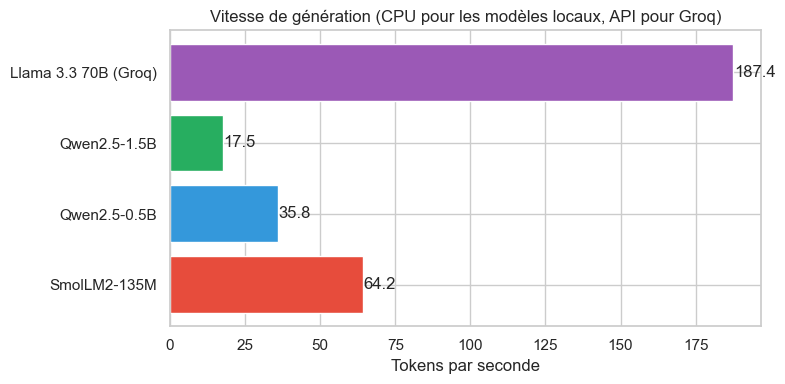

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_bench["Modèle"], df_bench["Tokens / s"],
        color=["#E74C3C", "#3498DB", "#27AE60", "#9B59B6"][:len(df_bench)])
ax.set_xlabel("Tokens par seconde")
ax.set_title(f"Vitesse de génération ({DEVICE.upper()} pour les modèles locaux, API pour Groq)")
for i, v in enumerate(df_bench["Tokens / s"]):
    ax.text(v + 0.3, i, f"{v}", va="center")
plt.tight_layout()
plt.show()


## 6.3 Grille de recommandation

Synthèse des observations pour guider le choix d'un modèle.

| Tâche | Taille recommandée | Commentaire |
|-------|-------------------|-------------|
| **Classification simple** (ticket → catégorie) | Petit modèle local (< 1B) | Few-shot + température 0 suffisent. Rapide, pas cher. |
| **Extraction structurée** (→ JSON) | Modèle moyen (1–7B) ou API | Le respect strict du format bénéficie d'un modèle plus grand. |
| **Résumé de documents longs** | API grand modèle + long contexte | Hallucinations fréquentes sur petits modèles. |
| **Traduction** | API grand modèle multilingue | Les petits modèles local ne couvrent pas bien le français/arabe. |
| **Génération SQL** | API grand modèle | Raisonnement sur schéma complexe → Llama 70B, GPT-4, Claude. |
| **Reformulation / style** | Modèle moyen (1–7B) | Équilibre qualité/coût. |
| **Chatbot simple FAQ** | Petit modèle local + RAG | Minimiser coût et latence, ancrage sur base de connaissances. |

### Règles pratiques

1. **Commencer petit**, tester, puis monter en gamme si nécessaire.
2. **Température = 0** pour tout ce qui doit être déterministe et reproductible.
3. **Few-shot** avant « plus grand modèle » — souvent ça suffit.
4. **RAG** avant « fine-tuning » — 10× moins cher, 10× plus rapide à itérer.
5. **Mesurer le coût** avant de mettre en production : tokens × volume × prix.

---

# PARTIE 7 — Synthèse et transition

## Ce que vous avez manipulé

- Trois LLM locaux de tailles différentes + un LLM distant via API (pattern OpenAI-compatible).
- Trois tokenizers, visualisation et coûts par langue.
- Embeddings de tokens et sentence embeddings, similarité cosinus, PCA, arithmétique vectorielle.
- Stratégies de décodage (greedy/sampling/beam), température, top-k/p, entropie, repetition penalty.
- Six cas d'usage métier : résumé, classification, traduction, extraction, SQL, reformulation.
- Perplexité, benchmark vitesse, grille de choix.

## Les 5 points à retenir

1. **Un LLM est une fonction probabiliste** qui prédit le token suivant — pas une base de connaissances.
2. **Le tokenizer conditionne le coût** : français ≈ 1,5× plus cher qu'anglais à sens équivalent.
3. **Les embeddings ne sont pas les mêmes pour tout** : sentence-transformers pour la similarité, embeddings LLM internes pour la génération.
4. **Température 0** pour tâches déterministes (extraction, classification), > 0 pour créativité (rédaction).
5. **Petit + Few-shot + RAG** bat souvent « grand modèle brut » en rapport qualité/coût.

## Transition vers le TP2 — Prompt Engineering

Ce TP a montré l'impact des **paramètres** (température, décodage). Le TP2 creusera l'autre levier : le **prompt**.

- Rôle, contexte, contraintes, exemples
- Chain-of-Thought, Self-Consistency, ReAct
- Prompt chaining et décomposition
- Mesure de qualité A/B
- Bibliothèque de prompts versionnée

**Préparation :** conservez votre clé Groq, on la réutilise au TP2.